In [15]:
import torch
from torch import nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np


In [16]:
# loading the dataset
iris_dataset = load_iris()
X = iris_dataset.data
y = iris_dataset.target
print(X.shape, y.shape)

(150, 4) (150,)


In [17]:
# Normalize feature values to [0,1] using standard scaling
X = MinMaxScaler().fit_transform(X)
print(X)

[[0.22222222 0.625      0.06779661 0.04166667]
 [0.16666667 0.41666667 0.06779661 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]
 [0.30555556 0.79166667 0.11864407 0.125     ]
 [0.08333333 0.58333333 0.06779661 0.08333333]
 [0.19444444 0.58333333 0.08474576 0.04166667]
 [0.02777778 0.375      0.06779661 0.04166667]
 [0.16666667 0.45833333 0.08474576 0.        ]
 [0.30555556 0.70833333 0.08474576 0.04166667]
 [0.13888889 0.58333333 0.10169492 0.04166667]
 [0.13888889 0.41666667 0.06779661 0.        ]
 [0.         0.41666667 0.01694915 0.        ]
 [0.41666667 0.83333333 0.03389831 0.04166667]
 [0.38888889 1.         0.08474576 0.125     ]
 [0.30555556 0.79166667 0.05084746 0.125     ]
 [0.22222222 0.625      0.06779661 0.08333333]
 [0.38888889 0.75       0.11864407 0.08333333]
 [0.22222222 0.75       0.08474576 0.08333333]
 [0.30555556 0.58333333 0.11864407 0.04166667]
 [0.22222222 

In [18]:
# One hot encoding of the target
y = OneHotEncoder().fit_transform(y.reshape(-1, 1)).toarray()
print(y.shape)

(150, 3)


In [19]:
# Split the dataset into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=5)


In [20]:
X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).float()

In [21]:
# Divide the trainset into batches
trainset = torch.utils.data.TensorDataset(X_train, y_train)
trainloader_2 = torch.utils.data.DataLoader(dataset=trainset, batch_size=2, shuffle=True)

In [22]:
# Divide the trainset into batches
trainloader_4 = torch.utils.data.DataLoader(dataset=trainset, batch_size=4, shuffle=True)

In [23]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        logits = self.fc2(x)
        x = torch.softmax(logits, dim=1)
        return logits, x

In [24]:
learning_rates = [0.001, 0.00001]
epochs = [1,3,5]

# For Batch Size = 2

C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


Epoch 1/1 Train Loss: 59.262316942214966
Epoch 1/1 Validation Loss: 1.119890809059143
ACCURACY
Accuracy for batch size 2, learning rate 0.001 and num epoch 1: 0.3333333333333333

F1 SCORE FOR BATCH SIZE 2, LEARNING RATE 0.001 AND 1 EPOCHS
F1 Score for setosa: 0.0000
F1 Score for versicolor: 0.0000
F1 Score for virginica: 0.5000
Average F1 Score: 0.1667

CONFUSION MATRIX FOR BATCH SIZE 2, LEARNING RATE 0.001 AND 1 EPOCHS
Confusion Matrix: 
[[ 0  0 10]
 [ 0  0 10]
 [ 0  0 10]]


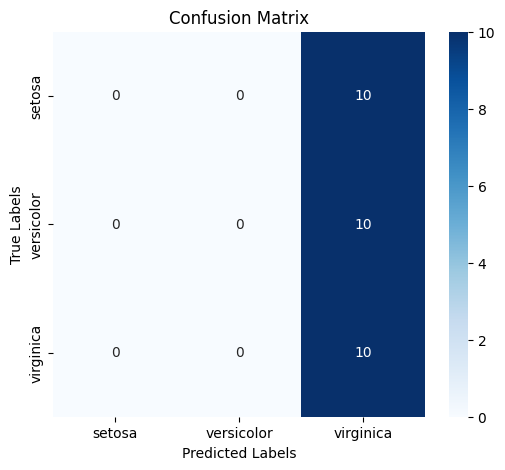


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 2 
Learning Rate = 0.001 
Epochs = 1
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: virginica
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: virginica
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: virginica
Epoch 1/3 Train Loss: 59.10639727115631
Epoch 1/3 Validation Loss: 1.129027009010315


C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


Epoch 2/3 Train Loss: 57.318559885025024
Epoch 2/3 Validation Loss: 1.1057288646697998
Epoch 3/3 Train Loss: 55.62063443660736
Epoch 3/3 Validation Loss: 1.0795611143112183
ACCURACY
Accuracy for batch size 2, learning rate 0.001 and num epoch 3: 0.3333333333333333

F1 SCORE FOR BATCH SIZE 2, LEARNING RATE 0.001 AND 3 EPOCHS
F1 Score for setosa: 0.0000
F1 Score for versicolor: 0.0000
F1 Score for virginica: 0.5000
Average F1 Score: 0.1667

CONFUSION MATRIX FOR BATCH SIZE 2, LEARNING RATE 0.001 AND 3 EPOCHS
Confusion Matrix: 
[[ 0  0 10]
 [ 0  0 10]
 [ 0  0 10]]


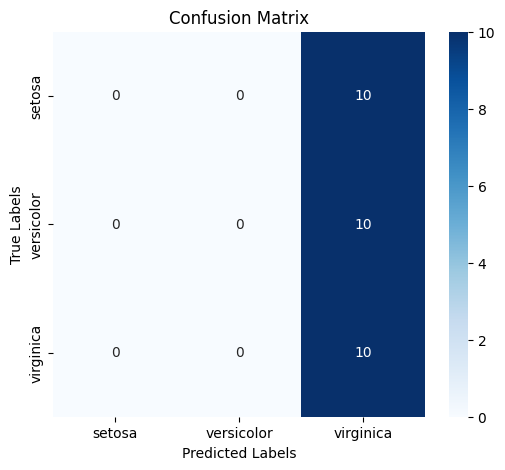


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 2 
Learning Rate = 0.001 
Epochs = 3
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: virginica
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: virginica
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: virginica


C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


Epoch 1/5 Train Loss: 56.57544416189194
Epoch 1/5 Validation Loss: 1.10542631149292
Epoch 2/5 Train Loss: 54.47329157590866
Epoch 2/5 Validation Loss: 1.0522749423980713
Epoch 3/5 Train Loss: 52.61577343940735
Epoch 3/5 Validation Loss: 1.0112923383712769
Epoch 4/5 Train Loss: 50.586233377456665
Epoch 4/5 Validation Loss: 0.9593207240104675
Epoch 5/5 Train Loss: 48.162006080150604
Epoch 5/5 Validation Loss: 0.8971816897392273
ACCURACY
Accuracy for batch size 2, learning rate 0.001 and num epoch 5: 0.8666666666666667

F1 SCORE FOR BATCH SIZE 2, LEARNING RATE 0.001 AND 5 EPOCHS
F1 Score for setosa: 0.9474
F1 Score for versicolor: 0.7778
F1 Score for virginica: 0.8696
Average F1 Score: 0.8649

CONFUSION MATRIX FOR BATCH SIZE 2, LEARNING RATE 0.001 AND 5 EPOCHS
Confusion Matrix: 
[[ 9  1  0]
 [ 0  7  3]
 [ 0  0 10]]


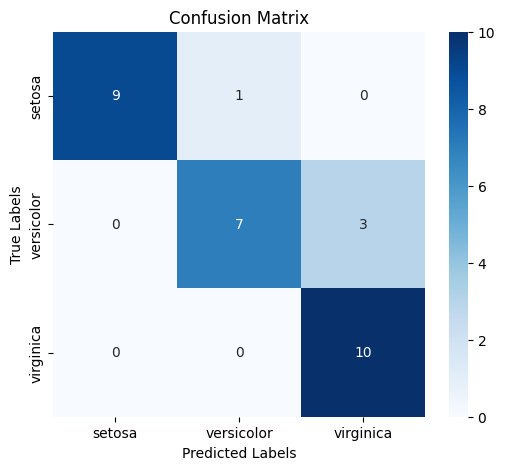


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 2 
Learning Rate = 0.001 
Epochs = 5
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: virginica
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: setosa
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: versicolor


C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


Epoch 1/1 Train Loss: 58.23640513420105
Epoch 1/1 Validation Loss: 1.0809093713760376
ACCURACY
Accuracy for batch size 2, learning rate 1e-05 and num epoch 1: 0.3333333333333333

F1 SCORE FOR BATCH SIZE 2, LEARNING RATE 1e-05 AND 1 EPOCHS
F1 Score for setosa: 0.5128
F1 Score for versicolor: 0.0000
F1 Score for virginica: 0.0000
Average F1 Score: 0.1709

CONFUSION MATRIX FOR BATCH SIZE 2, LEARNING RATE 1e-05 AND 1 EPOCHS
Confusion Matrix: 
[[10  0  0]
 [10  0  0]
 [ 9  1  0]]


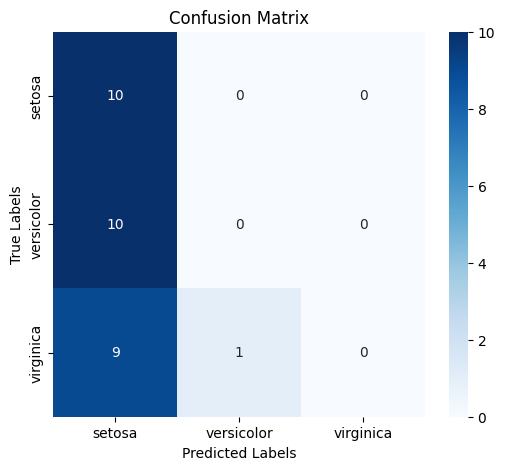


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 2 
Learning Rate = 1e-05 
Epochs = 1
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: setosa
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: setosa
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: setosa
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: setosa
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: setosa
Epoch 1/3 Train Loss: 61.361304581165314
Epoch 1/3 Validation Loss: 1.2021234035491943


C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


Epoch 2/3 Train Loss: 61.16252517700195
Epoch 2/3 Validation Loss: 1.201646089553833
Epoch 3/3 Train Loss: 61.206918478012085
Epoch 3/3 Validation Loss: 1.201203465461731
ACCURACY
Accuracy for batch size 2, learning rate 1e-05 and num epoch 3: 0.3333333333333333

F1 SCORE FOR BATCH SIZE 2, LEARNING RATE 1e-05 AND 3 EPOCHS
F1 Score for setosa: 0.0000
F1 Score for versicolor: 0.0000
F1 Score for virginica: 0.5000
Average F1 Score: 0.1667

CONFUSION MATRIX FOR BATCH SIZE 2, LEARNING RATE 1e-05 AND 3 EPOCHS
Confusion Matrix: 
[[ 0  0 10]
 [ 0  0 10]
 [ 0  0 10]]


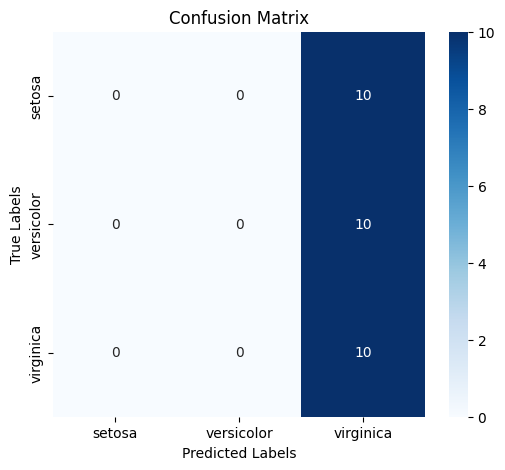


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 2 
Learning Rate = 1e-05 
Epochs = 3
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: virginica
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: virginica
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: virginica
Epoch 1/5 Train Loss: 57.76787328720093
Epoch 1/5 Validation Loss: 1.1455093622207642


C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\3896208356.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


Epoch 2/5 Train Loss: 57.835738599300385
Epoch 2/5 Validation Loss: 1.1452580690383911
Epoch 3/5 Train Loss: 57.74388438463211
Epoch 3/5 Validation Loss: 1.144958734512329
Epoch 4/5 Train Loss: 57.55912774801254
Epoch 4/5 Validation Loss: 1.1446610689163208
Epoch 5/5 Train Loss: 57.71918797492981
Epoch 5/5 Validation Loss: 1.1443449258804321
ACCURACY
Accuracy for batch size 2, learning rate 1e-05 and num epoch 5: 0.3333333333333333

F1 SCORE FOR BATCH SIZE 2, LEARNING RATE 1e-05 AND 5 EPOCHS
F1 Score for setosa: 0.0000
F1 Score for versicolor: 0.0000
F1 Score for virginica: 0.5000
Average F1 Score: 0.1667

CONFUSION MATRIX FOR BATCH SIZE 2, LEARNING RATE 1e-05 AND 5 EPOCHS
Confusion Matrix: 
[[ 0  0 10]
 [ 0  0 10]
 [ 0  0 10]]


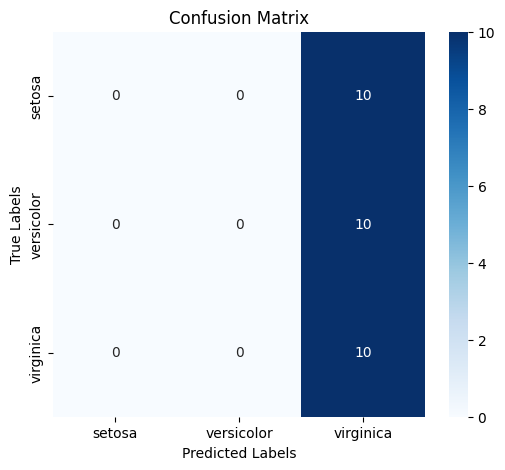


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 2 
Learning Rate = 1e-05 
Epochs = 5
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: virginica
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: virginica
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: virginica


In [25]:
# Training loop
loss_func = nn.CrossEntropyLoss()

for lr in learning_rates:
    for ep_num in epochs:
        train_loss = []
        val_loss = []
        mlp = MLP()
        optimizer = torch.optim.Adam(mlp.parameters(), lr=lr)
        n_epochs = ep_num
        for epoch in range(n_epochs):
            mlp.train()
            total_loss = 0
            for i, batch in enumerate(trainloader_2):
                optimizer.zero_grad()
                logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
                loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            # Tracking training loss
            train_loss.append(total_loss)
            print(f'Epoch {epoch+1}/{n_epochs} Train Loss: {total_loss}')

            # Tracking validation loss
            logits, y_pred_val = mlp(torch.tensor(X_val, dtype=torch.float32))
            loss_val = loss_func(logits, torch.argmax(torch.tensor(y_val, dtype=torch.float32), dim=1))
            val_loss.append(loss_val.item())
            print(f'Epoch {epoch+1}/{n_epochs} Validation Loss: {loss_val.item()}')

        # Test the model on the test set
        mlp.eval()
        logits_test, y_pred_test = mlp(torch.tensor(X_test, dtype=torch.float32))
        y_pred_test = torch.argmax(y_pred_test, dim=1).detach().numpy()
        y_test_i = torch.argmax(torch.tensor(y_test, dtype=torch.float32), dim=1).detach().numpy()

        # compute accuracy
        print("ACCURACY")
        accuracy = accuracy_score(y_test_i, y_pred_test)
        print(f'Accuracy for batch size 2, learning rate {lr} and num epoch {ep_num}: {accuracy}')
        # compute f1 score
        print(f"\nF1 SCORE FOR BATCH SIZE 2, LEARNING RATE {lr} AND {ep_num} EPOCHS")
        f1 = f1_score(y_test_i, y_pred_test, average=None)
        print(f'F1 Score for {iris_dataset.target_names[0]}: {f1[0]:.4f}')
        print(f'F1 Score for {iris_dataset.target_names[1]}: {f1[1]:.4f}')
        print(f'F1 Score for {iris_dataset.target_names[2]}: {f1[2]:.4f}')
        print(f'Average F1 Score: {f1.mean():.4f}')

        # compute confusion matrix
        print(f"\nCONFUSION MATRIX FOR BATCH SIZE 2, LEARNING RATE {lr} AND {ep_num} EPOCHS")
        confusion_mat = confusion_matrix(y_test_i, y_pred_test)
        print(f'Confusion Matrix: \n{confusion_mat}')

        # visualize confusion matrix using matplotlib
        class_labels = ['setosa' ,'versicolor' ,'virginica']
        plt.figure(figsize=(6, 5))
        sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_labels, yticklabels=class_labels)

        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title('Confusion Matrix')
        plt.show()

        # testing the model on 5 values from test dataset
        print(f"\n TESTING THE MODEL ON 5 VALUES FROM TEST DATASET")
        print(f"Model parameters: \nBatch Size = 2 \nLearning Rate = {lr} \nEpochs = {ep_num}")
        for i in range(5):
          print(f"Example {i}: {X_test[i]}")
          print(f'Actual Label: {iris_dataset.target_names[y_test_i[i]]}')
          print(f'Predicted Label: {iris_dataset.target_names[y_pred_test[i]]}')

# For Batch Size = 4

Epoch 1/1 Train Loss: 29.922856152057648
Epoch 1/1 Validation Loss: 1.1012022495269775
ACCURACY
Accuracy for batch size 4, learning rate 0.001 and num epoch 1: 0.3333333333333333

F1 SCORE FOR BATCH SIZE 4, LEARNING RATE 0.001 AND 1 EPOCHS
F1 Score for setosa: 0.0000
F1 Score for versicolor: 0.5000
F1 Score for virginica: 0.0000
Average F1 Score: 0.1667

CONFUSION MATRIX FOR BATCH SIZE 4, LEARNING RATE 0.001 AND 1 EPOCHS
Confusion Matrix: 
[[ 0 10  0]
 [ 0 10  0]
 [ 0 10  0]]


C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


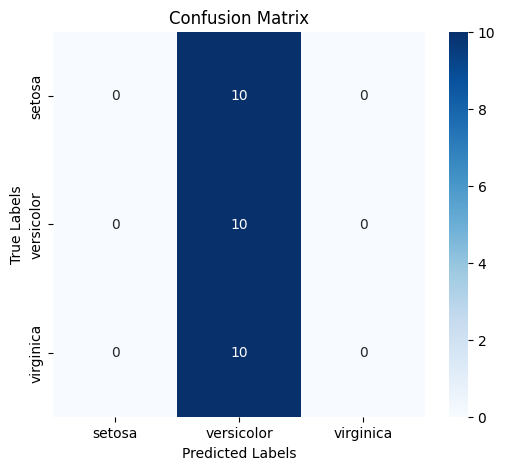


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 4 
Learning Rate = 0.001 
Epochs = 1
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: versicolor
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: versicolor
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: versicolor
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: versicolor
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: versicolor
Epoch 1/3 Train Loss: 30.019225358963013
Epoch 1/3 Validation Loss: 1.1269892454147339


C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


Epoch 2/3 Train Loss: 29.599234461784363
Epoch 2/3 Validation Loss: 1.113968014717102
Epoch 3/3 Train Loss: 28.877332627773285
Epoch 3/3 Validation Loss: 1.0985313653945923
ACCURACY
Accuracy for batch size 4, learning rate 0.001 and num epoch 3: 0.3333333333333333

F1 SCORE FOR BATCH SIZE 4, LEARNING RATE 0.001 AND 3 EPOCHS
F1 Score for setosa: 0.0000
F1 Score for versicolor: 0.0000
F1 Score for virginica: 0.5000
Average F1 Score: 0.1667

CONFUSION MATRIX FOR BATCH SIZE 4, LEARNING RATE 0.001 AND 3 EPOCHS
Confusion Matrix: 
[[ 0  0 10]
 [ 0  0 10]
 [ 0  0 10]]


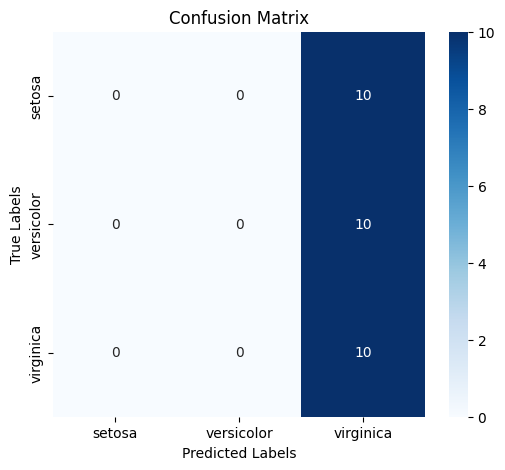


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 4 
Learning Rate = 0.001 
Epochs = 3
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: virginica
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: virginica
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: virginica
Epoch 1/5 Train Loss: 32.33870869874954
Epoch 1/5 Validation Loss: 1.0824406147003174
Epoch 2/5 Train Loss: 30.549874365329742
Epoch 2/5 Validation Loss: 1.0515210628509521


C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


Epoch 3/5 Train Loss: 29.60483682155609
Epoch 3/5 Validation Loss: 1.0209978818893433
Epoch 4/5 Train Loss: 28.483417332172394
Epoch 4/5 Validation Loss: 0.9915270209312439
Epoch 5/5 Train Loss: 27.425296008586884
Epoch 5/5 Validation Loss: 0.9467567801475525
ACCURACY
Accuracy for batch size 4, learning rate 0.001 and num epoch 5: 0.7

F1 SCORE FOR BATCH SIZE 4, LEARNING RATE 0.001 AND 5 EPOCHS
F1 Score for setosa: 1.0000
F1 Score for versicolor: 0.6897
F1 Score for virginica: 0.1818
Average F1 Score: 0.6238

CONFUSION MATRIX FOR BATCH SIZE 4, LEARNING RATE 0.001 AND 5 EPOCHS
Confusion Matrix: 
[[10  0  0]
 [ 0 10  0]
 [ 0  9  1]]


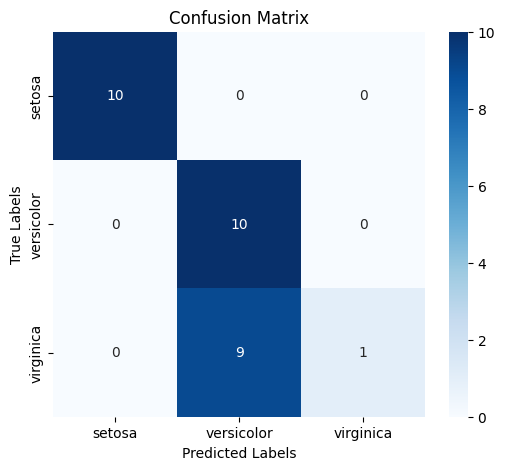


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 4 
Learning Rate = 0.001 
Epochs = 5
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: versicolor
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: versicolor
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: versicolor
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: setosa
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: versicolor
Epoch 1/1 Train Loss: 29.15103191137314
Epoch 1/1 Validation Loss: 1.0886919498443604
ACCURACY
Accuracy for batch size 4, learning rate 1e-05 and num epoch 1: 0.3333333333333333

F1 SCORE FOR BATCH SIZE 4, LEARNING RATE 1e-05 AND 1 EPOCHS
F1 Score for setosa: 0.0000
F1 Score for versicolor: 0.0000
F1 Score for virginica: 0.5000
Average F1 S

C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


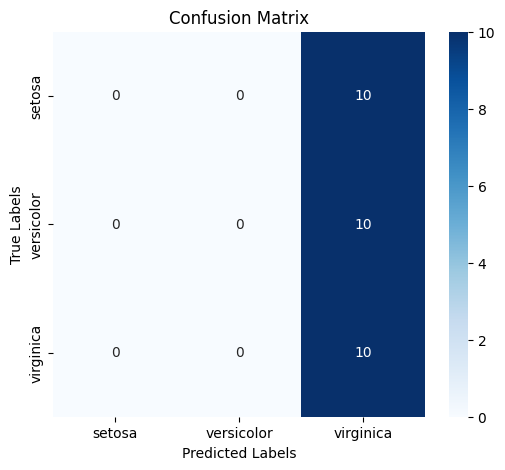


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 4 
Learning Rate = 1e-05 
Epochs = 1
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: virginica
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: virginica
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: virginica
Epoch 1/3 Train Loss: 30.018993973731995
Epoch 1/3 Validation Loss: 1.1786236763000488
Epoch 2/3 Train Loss: 30.21945583820343
Epoch 2/3 Validation Loss: 1.178436517715454


C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


Epoch 3/3 Train Loss: 30.223193407058716
Epoch 3/3 Validation Loss: 1.1782292127609253
ACCURACY
Accuracy for batch size 4, learning rate 1e-05 and num epoch 3: 0.3333333333333333

F1 SCORE FOR BATCH SIZE 4, LEARNING RATE 1e-05 AND 3 EPOCHS
F1 Score for setosa: 0.0000
F1 Score for versicolor: 0.0000
F1 Score for virginica: 0.5000
Average F1 Score: 0.1667

CONFUSION MATRIX FOR BATCH SIZE 4, LEARNING RATE 1e-05 AND 3 EPOCHS
Confusion Matrix: 
[[ 0  0 10]
 [ 0  0 10]
 [ 0  0 10]]


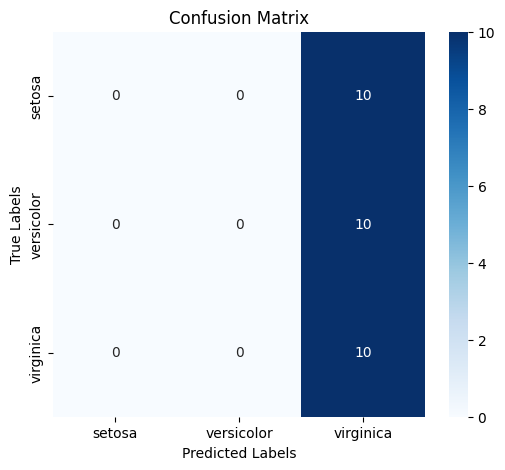


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 4 
Learning Rate = 1e-05 
Epochs = 3
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: virginica
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: virginica
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: virginica
Epoch 1/5 Train Loss: 30.26646637916565
Epoch 1/5 Validation Loss: 1.1437028646469116
Epoch 2/5 Train Loss: 30.26931095123291
Epoch 2/5 Validation Loss: 1.1434669494628906


C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
C:\Users\1511l\AppData\Local\Temp\ipykernel_31296\2099292546.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))


Epoch 3/5 Train Loss: 29.85843849182129
Epoch 3/5 Validation Loss: 1.1432533264160156
Epoch 4/5 Train Loss: 30.242053985595703
Epoch 4/5 Validation Loss: 1.1430610418319702
Epoch 5/5 Train Loss: 30.17263752222061
Epoch 5/5 Validation Loss: 1.1428176164627075
ACCURACY
Accuracy for batch size 4, learning rate 1e-05 and num epoch 5: 0.3333333333333333

F1 SCORE FOR BATCH SIZE 4, LEARNING RATE 1e-05 AND 5 EPOCHS
F1 Score for setosa: 0.0000
F1 Score for versicolor: 0.0000
F1 Score for virginica: 0.5000
Average F1 Score: 0.1667

CONFUSION MATRIX FOR BATCH SIZE 4, LEARNING RATE 1e-05 AND 5 EPOCHS
Confusion Matrix: 
[[ 0  0 10]
 [ 0  0 10]
 [ 0  0 10]]


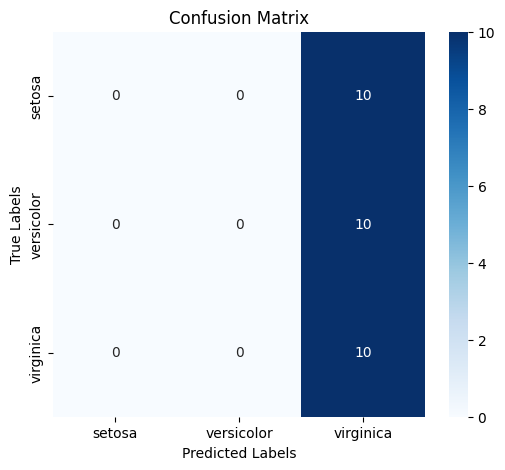


 TESTING THE MODEL ON 5 VALUES FROM TEST DATASET
Model parameters: 
Batch Size = 4 
Learning Rate = 1e-05 
Epochs = 5
Example 0: [0.55555556 0.58333333 0.77966102 0.95833333]
Actual Label: virginica
Predicted Label: virginica
Example 1: [0.5        0.41666667 0.66101695 0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 2: [0.47222222 0.41666667 0.6440678  0.70833333]
Actual Label: virginica
Predicted Label: virginica
Example 3: [0.30555556 0.79166667 0.11864407 0.125     ]
Actual Label: setosa
Predicted Label: virginica
Example 4: [0.19444444 0.125      0.38983051 0.375     ]
Actual Label: versicolor
Predicted Label: virginica


In [26]:
# Lists for storing training and validation loss
train_loss = []
val_loss = []

# Training loop
loss_func = nn.CrossEntropyLoss()

for lr in learning_rates:
    for ep_num in epochs:
        mlp = MLP()
        optimizer = torch.optim.Adam(mlp.parameters(), lr=lr)
        n_epochs = ep_num
        for epoch in range(n_epochs):
            mlp.train()
            total_loss = 0
            for i, batch in enumerate(trainloader_4):
                optimizer.zero_grad()
                logits, y_pred = mlp(torch.tensor(batch[0], dtype=torch.float32))
                loss = loss_func(logits, torch.argmax(torch.tensor(batch[1], dtype=torch.float32), dim=1))
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            # Tracking training loss
            train_loss.append(total_loss)
            print(f'Epoch {epoch+1}/{n_epochs} Train Loss: {total_loss}')

            # Tracking validation loss
            logits, y_pred_val = mlp(torch.tensor(X_val, dtype=torch.float32))
            loss_val = loss_func(logits, torch.argmax(torch.tensor(y_val, dtype=torch.float32), dim=1))
            val_loss.append(loss_val.item())
            print(f'Epoch {epoch+1}/{n_epochs} Validation Loss: {loss_val.item()}')

        # Test the model on the test set
        mlp.eval()
        logits_test, y_pred_test = mlp(torch.tensor(X_test, dtype=torch.float32))
        y_pred_test = torch.argmax(y_pred_test, dim=1).detach().numpy()
        y_test_i = torch.argmax(torch.tensor(y_test, dtype=torch.float32), dim=1).detach().numpy()

        # compute accuracy
        print("ACCURACY")
        accuracy = accuracy_score(y_test_i, y_pred_test)
        print(f'Accuracy for batch size 4, learning rate {lr} and num epoch {ep_num}: {accuracy}')
        # compute f1 score
        print(f"\nF1 SCORE FOR BATCH SIZE 4, LEARNING RATE {lr} AND {ep_num} EPOCHS")
        f1 = f1_score(y_test_i, y_pred_test, average=None)
        print(f'F1 Score for {iris_dataset.target_names[0]}: {f1[0]:.4f}')
        print(f'F1 Score for {iris_dataset.target_names[1]}: {f1[1]:.4f}')
        print(f'F1 Score for {iris_dataset.target_names[2]}: {f1[2]:.4f}')
        print(f'Average F1 Score: {f1.mean():.4f}')

        # compute confusion matrix
        print(f"\nCONFUSION MATRIX FOR BATCH SIZE 4, LEARNING RATE {lr} AND {ep_num} EPOCHS")
        confusion_mat = confusion_matrix(y_test_i, y_pred_test)
        print(f'Confusion Matrix: \n{confusion_mat}')

        # visualize confusion matrix using matplotlib
        class_labels = ['setosa' ,'versicolor' ,'virginica']
        plt.figure(figsize=(6, 5))
        sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_labels, yticklabels=class_labels)

        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title('Confusion Matrix')
        plt.show()

        # testing the model on 5 values from test dataset
        print(f"\n TESTING THE MODEL ON 5 VALUES FROM TEST DATASET")
        print(f"Model parameters: \nBatch Size = 4 \nLearning Rate = {lr} \nEpochs = {ep_num}")
        for i in range(5):
          print(f"Example {i}: {X_test[i]}")
          print(f'Actual Label: {iris_dataset.target_names[y_test_i[i]]}')
          print(f'Predicted Label: {iris_dataset.target_names[y_pred_test[i]]}')